# Задание 1. Загрузка данных

Изучить представленный набор данных на основе описания его столбцов в файле “horse_data.names” , загрузить его и оставить 8 столбцов для дальнейшего изучения: surgery?, Age, rectal temperature, pulse, respiratory rate, temperature of extremities, pain, outcome.

In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv('/content/horse_data.csv', header=None).iloc[:, [0,1,3,4,5,6,10,22]]
df.columns = ['surgery?',
              'age',
              'rectal_temperature',
              'pulse',
              'respiratory_rate',
              'temperature_of_extremities',
              'pain',
              'outcome']

In [ ]:
df.replace('?', None, inplace=True)

In [ ]:
dt_dict = {
    'surgery?': 'float64',
    'age': 'float64',
    'rectal_temperature': 'float64',
    'pulse': 'float64',
    'respiratory_rate': 'float64',
    'temperature_of_extremities': 'float64',
    'pain': 'float64',
    'outcome': 'float64'
}
df = df.astype(dt_dict, errors='ignore')

In [ ]:
df.head()

,surgery?,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,pain,outcome
0,2,1,38.5,66,28,3,5,2
1,1,1,39.2,88,20,<NA>,3,3
2,2,1,38.3,40,24,1,3,1
3,1,9,39.1,164,84,4,2,2
4,2,1,37.3,104,35,<NA>,<NA>,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   surgery?                    300 non-null    float64
 1   age                         300 non-null    float64
 2   rectal_temperature          300 non-null    float64
 3   pulse                       300 non-null    float64
 4   respiratory_rate            242 non-null    float64
 5   temperature_of_extremities  244 non-null    float64
 6   pain                        300 non-null    float64
 7   outcome                     300 non-null    float64
dtypes: float64(8)
memory usage: 18.9 KB


# Задание 2. Первичное изучение данных
Проанализировать значения по столбцам, рассчитать базовые статистики, найти выбросы.

In [ ]:
# Расчет баховых статистик
df.describe()

,surgery?,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,pain,outcome
count,299.0,300.0,240.000000,276.0,242.0,244.0,245.0,299.0
mean,1.397993,1.64,38.167917,71.913043,30.417355,2.348361,2.95102,1.551839
std,0.490305,2.173972,0.732289,28.630557,17.642231,1.045054,1.30794,0.737187
min,1.0,1.0,35.400000,30.0,8.0,1.0,1.0,1.0
25%,1.0,1.0,37.800000,48.0,18.5,1.0,2.0,1.0
50%,1.0,1.0,38.200000,64.0,24.5,3.0,3.0,1.0
75%,2.0,1.0,38.500000,88.0,36.0,3.0,4.0,2.0
max,2.0,9.0,40.800000,184.0,96.0,4.0,5.0,3.0


In [ ]:
# медиана
df.median()

,0
surgery?,1.0
age,1.0
rectal_temperature,38.2
pulse,64.0
respiratory_rate,24.5
temperature_of_extremities,3.0
pain,3.0
outcome,1.0


In [ ]:
# мода
df.mode()

,surgery?,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,pain,outcome
0,1,1,38.0,48,20,3,3,1


In [ ]:
# возможные значения: [1, 2]
# все остальное - выбросы
df.loc[:, 'surgery?'].unique()
# выбросов нет

<IntegerArray>
[2, 1, <NA>]
Length: 3, dtype: Int64

In [ ]:
# допустимые значения
# 1 = Adult horse
# 2 = Young (< 6 months)
# все отсальное выбросы
# мах = 9 -> есть выбросы
out_cnt = len(df.loc[~df['age'].isin([0, 1]), 'age'])
outfs = df.loc[~df['age'].isin([0, 1]), 'age']
print(f'Количество выбросов: {out_cnt} | {out_cnt / 300 * 100}%')
print(f'Выбросы: {outfs.to_list()}')

Количество выбросов: 24 | 8.0%
Выбросы: [9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]


In [ ]:
# в норме составляет 37.8
# мах = 40.8 является допустимым значением, если лошадь больна
# мин = 35.4 выглядит не особо реальным, возможно замер температуры проводился не достаточно долго
# будем искать выбросы меньшие 37.8

q1 = df['rectal_temperature'].quantile(0.25)
q3 = df['rectal_temperature'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5*iqr
out_cnt = len(df.loc[df['rectal_temperature'] < lower_bound, 'rectal_temperature'])
outfs = df.loc[df['rectal_temperature'] < lower_bound, 'rectal_temperature']
print(f'Количество выбросов: {out_cnt} | {out_cnt / 240 * 100}%')
print(f'Выбросы: {outfs.to_list()}')

Количество выбросов: 7 | 2.9166666666666665%
Выбросы: [35.4, 36.4, 36.5, 36.0, 36.1, 36.6, 36.5]


<Axes: >

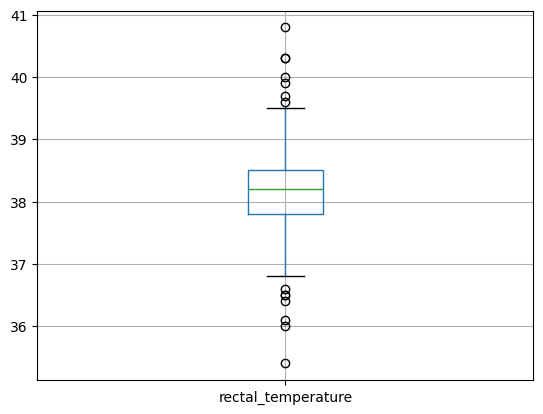

In [ ]:
df[['rectal_temperature']].boxplot()

In [ ]:
# для взрослых в норме 30-40
# для спортивных допустимо 20-25
# у больных может быть повышен
df.loc[df['age'] == 2]
# в представленном наборе отсутствуют молодые лошади

,surgery?,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,pain,outcome


(<Axes: >, <Axes: ylabel='Frequency'>)

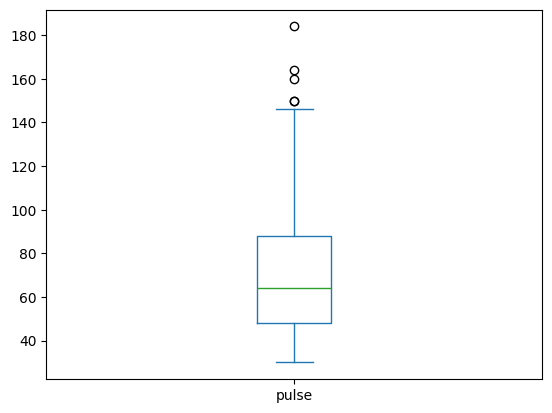

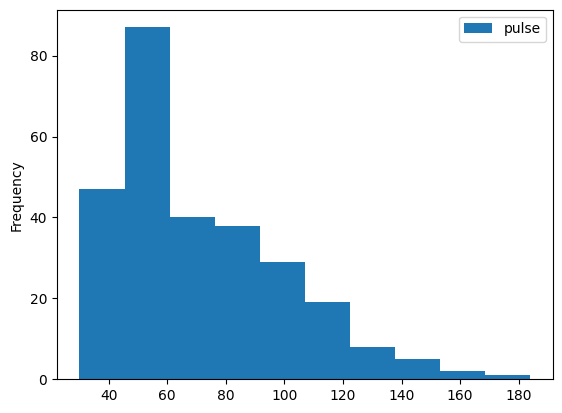

In [ ]:
df[['pulse']].plot(kind='box'), df[['pulse']].plot(kind='hist')
# присутствуют выбросы по верхней границе

In [ ]:
q1 = df['pulse'].quantile(0.25)
q3 = df['pulse'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5*iqr
out_cnt = len(df.loc[df['pulse'] > upper_bound, 'pulse'])
outfs = df.loc[df['pulse'] > upper_bound, 'pulse']
print(f'Количество выбросов: {out_cnt} | {out_cnt / 276 * 100}%')
print(f'Выбросы: {outfs.to_list()}')

Количество выбросов: 5 | 1.8115942028985508%
Выбросы: [164, 150, 160, 184, 150]


In [ ]:
from scipy import stats

# respiratory_rate
z_respiratory_rate_value = stats.zscore(df['respiratory_rate'].dropna())
out_indxs = df['respiratory_rate'].dropna().index[(z_respiratory_rate_value > 2) | (z_respiratory_rate_value < -2)]
out_cnt = len(df.loc[out_indxs, 'respiratory_rate'])
outfs = df.loc[out_indxs, 'respiratory_rate']

print(f'Количество выбросов: {out_cnt} | {out_cnt / 242 * 100}%')
print(f'Выбросы: {outfs.to_list()}')


Количество выбросов: 17 | 7.024793388429752%
Выбросы: [84, 96, 72, 80, 80, 68, 96, 66, 68, 90, 80, 70, 88, 84, 68, 90, 70]


In [ ]:
# temperature_of_extremities
# возможные значения:
# 1 = Normal
# 2 = Warm
# 3 = Cool
# 4 = Cold
df['temperature_of_extremities'].unique() # -> выбросов нет

<IntegerArray>
[3, <NA>, 1, 4, 2]
Length: 5, dtype: Int64

In [ ]:
# pain
# возможные значения:
# 1 = alert, no pain
# 2 = depressed
# 3 = intermittent mild pain
# 4 = intermittent severe pain
# 5 = continuous severe pain

df['pain'].unique() # -> выбросов нет

<IntegerArray>
[5, 3, 2, <NA>, 4, 1]
Length: 6, dtype: Int64

In [ ]:
# outcome
# возможные значения:
# 1 = lived
# 2 = died
# 3 = was euthanized

df['outcome'].unique() # -> выбросов нет

<IntegerArray>
[2, 3, 1, <NA>]
Length: 4, dtype: Int64

# Задание 3. Работа с пропусками
Рассчитать количество пропусков для всех выбранных столбцов. Принять и обосновать решение о методе заполнения пропусков по каждому столбцу на основе рассчитанных статистик и возможной взаимосвязи значений в них. Сформировать датафрейм, в котором пропуски будут отсутствовать.

In [ ]:
df.isna().sum()

,0
surgery?,1
age,0
rectal_temperature,60
pulse,24
respiratory_rate,58
temperature_of_extremities,56
pain,55
outcome,1


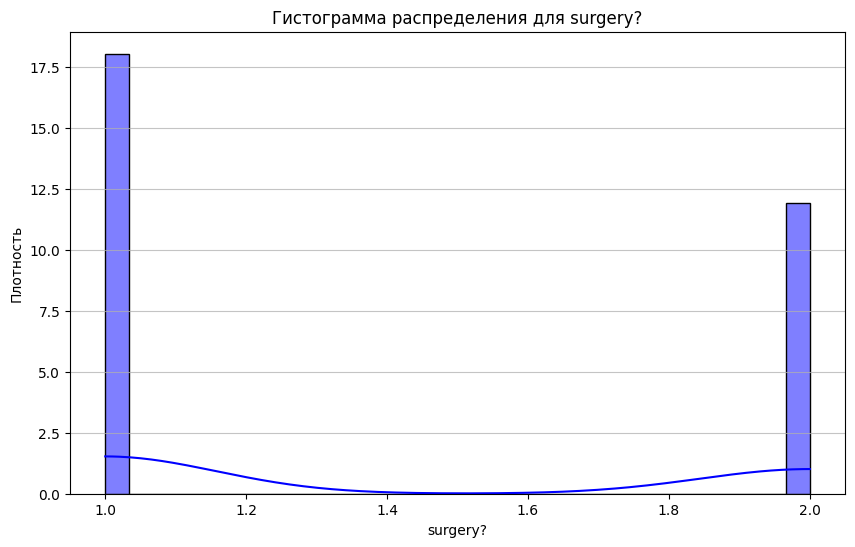

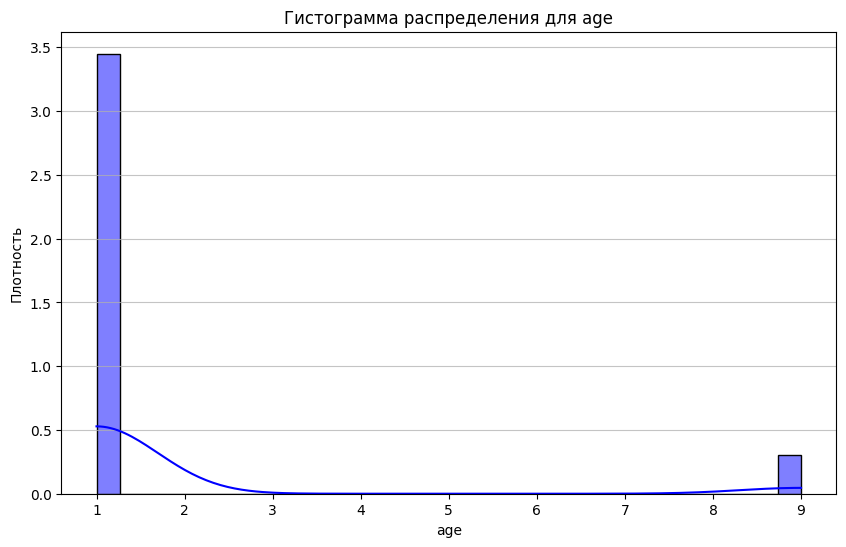

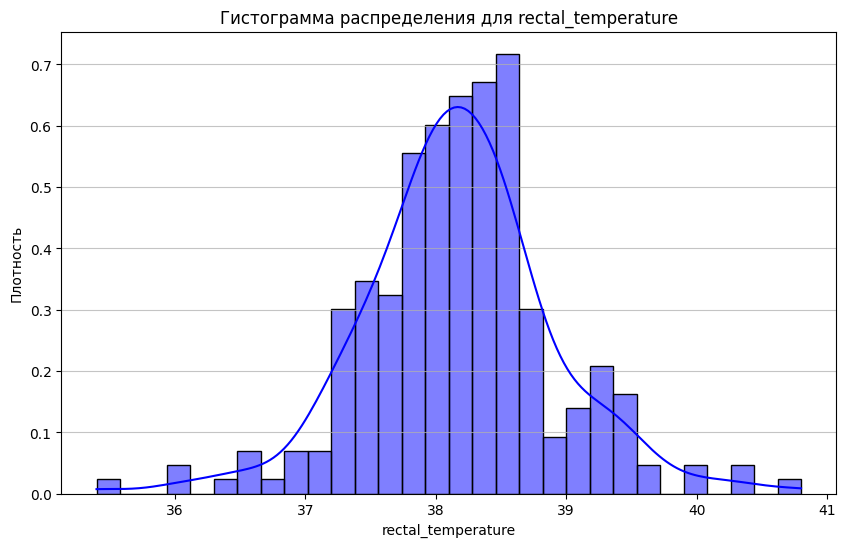

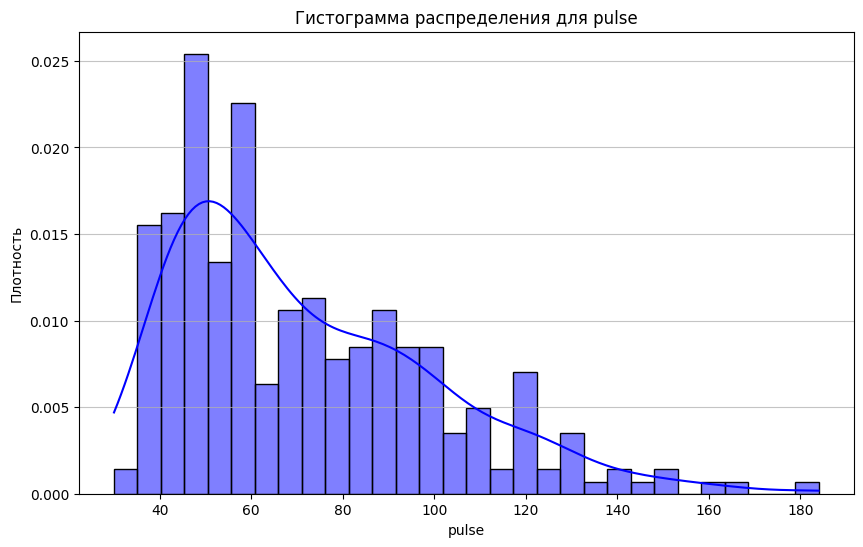

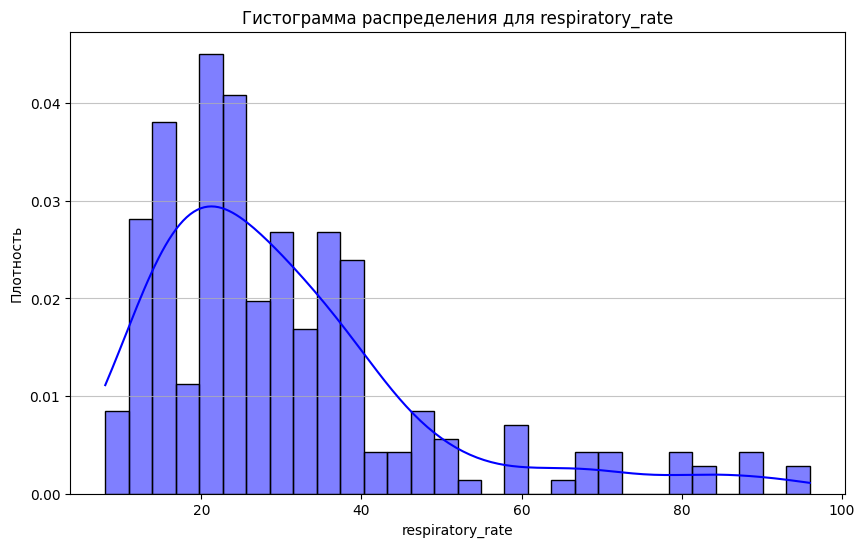

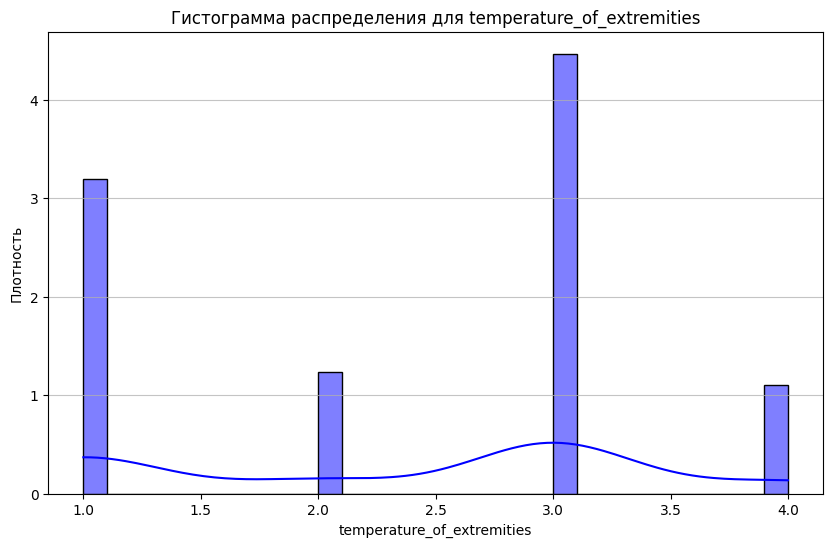

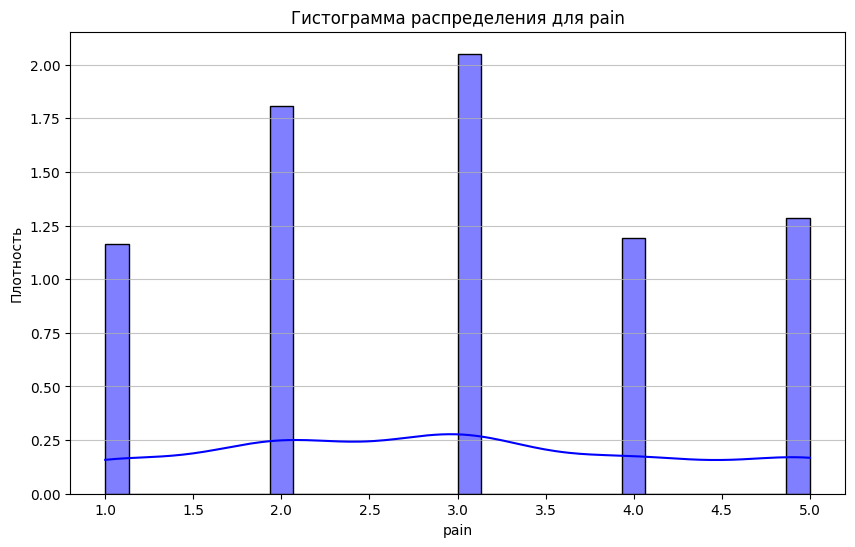

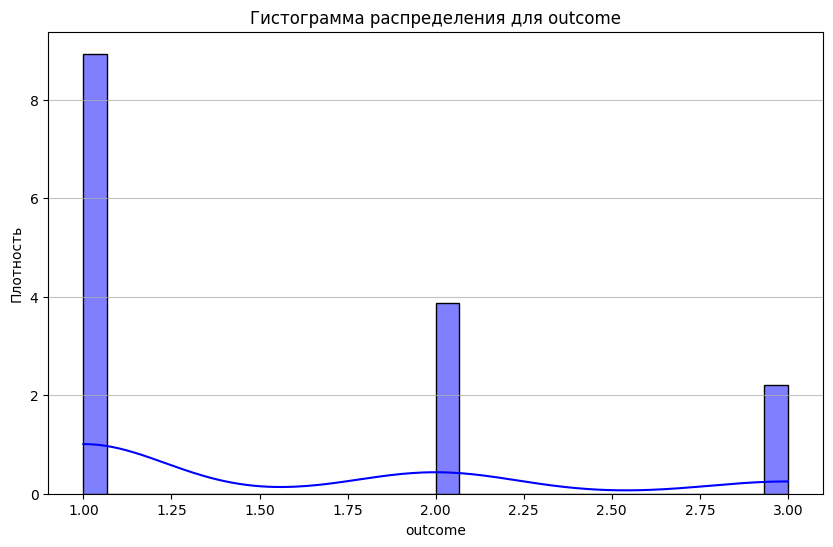

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

for column in df.columns:
    plt.figure(figsize=(10, 6))
    sns.histplot(df[column].dropna(), bins=30, kde=True, color='blue', stat='density')
    plt.title(f'Гистограмма распределения для {column}')
    plt.xlabel(column)
    plt.ylabel('Плотность')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

все признаки имеют унимодальные распределения, поэтому будем заполнять пропуски у категориальных столбцов модой, как самой устойчивой к выбросам величиной
в количественных столбцах медианой

In [ ]:
for column in ['surgery?', 'age', 'pain', 'outcome']:
    mode_value = df[column].mode()[0]
    df[column].fillna(mode_value, inplace=True)

for column in ['rectal_temperature','pulse',	'respiratory_rate',	'temperature_of_extremities']:
    median_value = df[column].median()
    df[column].fillna(median_value, inplace=True)

print(df.isnull().sum()) # столбцы не содержать пропуски

surgery?                      0
age                           0
rectal_temperature            0
pulse                         0
respiratory_rate              0
temperature_of_extremities    0
pain                          0
outcome                       0
dtype: int64


<ipython-input-79-5c075ed44b12>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[column].fillna(mode_value, inplace=True)
<ipython-input-79-5c075ed44b12>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df

In [ ]:
df.head()

,surgery?,age,rectal_temperature,pulse,respiratory_rate,temperature_of_extremities,pain,outcome
0,2.0,1.0,38.5,66.0,28.0,3.0,5.0,2.0
1,1.0,1.0,39.2,88.0,20.0,3.0,3.0,3.0
2,2.0,1.0,38.3,40.0,24.0,1.0,3.0,1.0
3,1.0,9.0,39.1,164.0,84.0,4.0,2.0,2.0
4,2.0,1.0,37.3,104.0,35.0,3.0,3.0,2.0
